In [8]:
import joblib
import pandas as pd
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score
)

# Load model
model = joblib.load("../Data/CatBoost_Final_Research_Model.pkl")

# Load data
df = pd.read_csv("../Data/test_2023_2025.csv")

# Remove unused columns
df = df.drop(columns=["Date", "Time"])

TARGET = "Thunderstorm_24h"

X_test = df.drop(columns=[TARGET])
y_test = df[TARGET]

# Predict probabilities
test_prob = model.predict_proba(X_test)[:, 1]

# Final threshold
THRESHOLD = 0.32

test_pred = (test_prob >= THRESHOLD).astype(int)

print(confusion_matrix(y_test, test_pred))
print(classification_report(y_test, test_pred))
print("ROC AUC:", roc_auc_score(y_test, test_prob))

[[981 238]
 [ 60 113]]
              precision    recall  f1-score   support

           0       0.94      0.80      0.87      1219
           1       0.32      0.65      0.43       173

    accuracy                           0.79      1392
   macro avg       0.63      0.73      0.65      1392
weighted avg       0.87      0.79      0.81      1392

ROC AUC: 0.7990369249882638


In [9]:
import pandas as pd

In [10]:
import pandas as pd

train_df = pd.read_csv("../Data/train_2000_2020.csv")

train_df = train_df.drop(columns=["Date", "Time"])

TARGET = "Thunderstorm_24h"

X_train = train_df.drop(columns=[TARGET])

In [11]:
# ============================================================
# FEATURE RANKING
# ============================================================

feature_importance = pd.DataFrame({

    "Feature": X_train.columns,

    "Importance": model.feature_importances_

})

feature_importance = feature_importance.sort_values(

    by="Importance",

    ascending=False

).reset_index(drop=True)

feature_importance.index += 1

feature_importance.index.name = "Rank"

display(feature_importance)

,Feature,Importance
Rank,,
1,PW,24.793223
2,MML_PT,8.774427
3,THETAE_LCL,7.464047
4,KI,6.439376
5,TT,5.020140
6,LCL_T,4.965786
7,SWEAT,4.681135
8,LCL_P,4.192091
9,LFC,4.188094


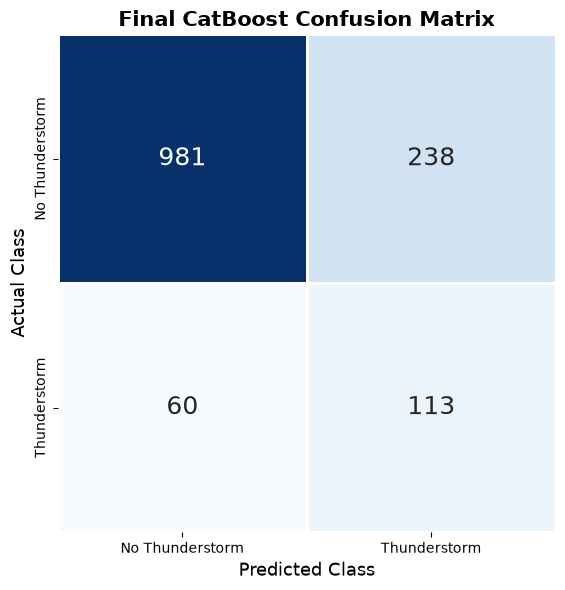

In [12]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, test_pred)

plt.figure(figsize=(7,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    linewidths=1,
    square=True,
    annot_kws={"size":18},
    xticklabels=["No Thunderstorm","Thunderstorm"],
    yticklabels=["No Thunderstorm","Thunderstorm"]
)

plt.xlabel("Predicted Class",fontsize=13)
plt.ylabel("Actual Class",fontsize=13)
plt.title("Final CatBoost Confusion Matrix",fontsize=15,fontweight="bold")

plt.tight_layout()

plt.savefig("Final_Confusion_Matrix.png",dpi=300)

plt.show()

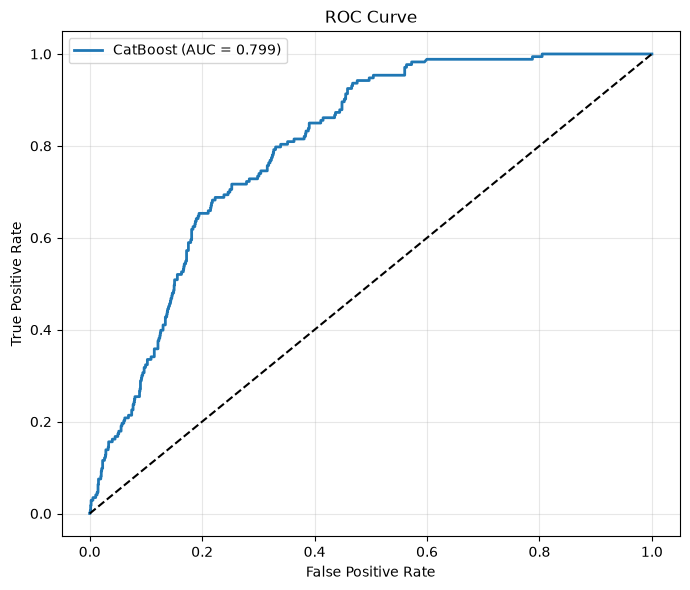

In [13]:
from sklearn.metrics import roc_curve, auc

fpr,tpr,_ = roc_curve(y_test,test_prob)

roc_auc = auc(fpr,tpr)

plt.figure(figsize=(7,6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"CatBoost (AUC = {roc_auc:.3f})"
)

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig("ROC_Curve.png",dpi=300)

plt.show()

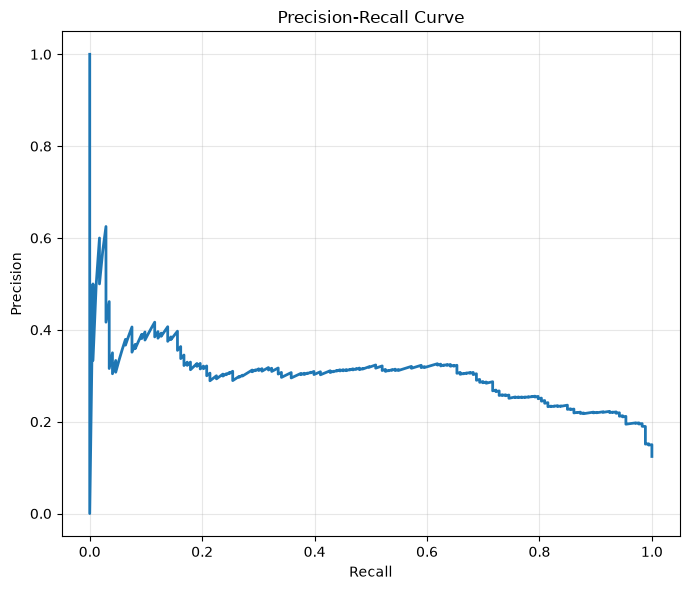

In [14]:
from sklearn.metrics import precision_recall_curve

precision,recall,_ = precision_recall_curve(
    y_test,
    test_prob
)

plt.figure(figsize=(7,6))

plt.plot(
    recall,
    precision,
    linewidth=2
)

plt.xlabel("Recall")

plt.ylabel("Precision")

plt.title("Precision-Recall Curve")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig("Precision_Recall_Curve.png",dpi=300)

plt.show()

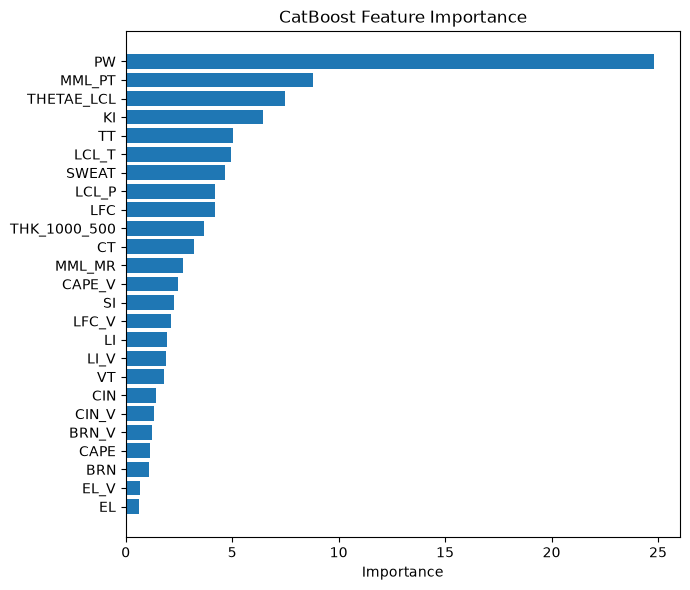

In [25]:
feature_importance = pd.DataFrame({

    "Feature":X_test.columns,

    "Importance":model.feature_importances_

})

feature_importance = feature_importance.sort_values(

    by="Importance",

    ascending=True

)

plt.figure(figsize=(7,6))

plt.barh(

    feature_importance["Feature"],

    feature_importance["Importance"]

)

plt.xlabel("Importance")

plt.title("CatBoost Feature Importance")

plt.tight_layout()

plt.savefig("Feature_Importance.png",dpi=300)

plt.show()


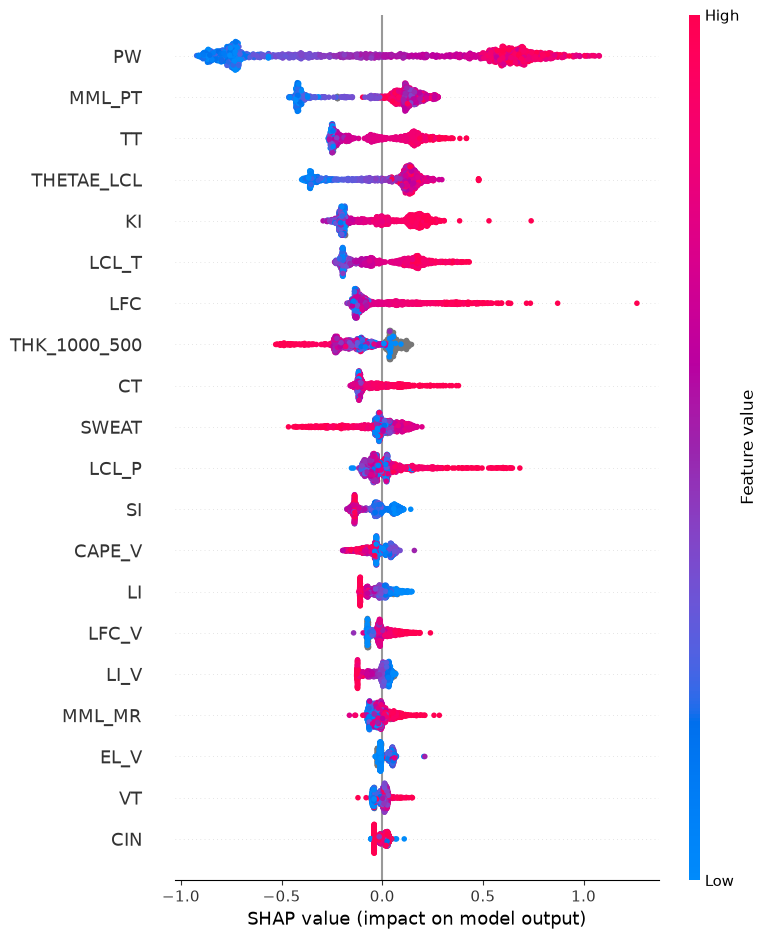

In [20]:
import shap

explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_test)

shap.summary_plot(

    shap_values,

    X_test,

    show=False

)

plt.tight_layout()

plt.savefig("SHAP_Summary.png",dpi=300)

plt.show()

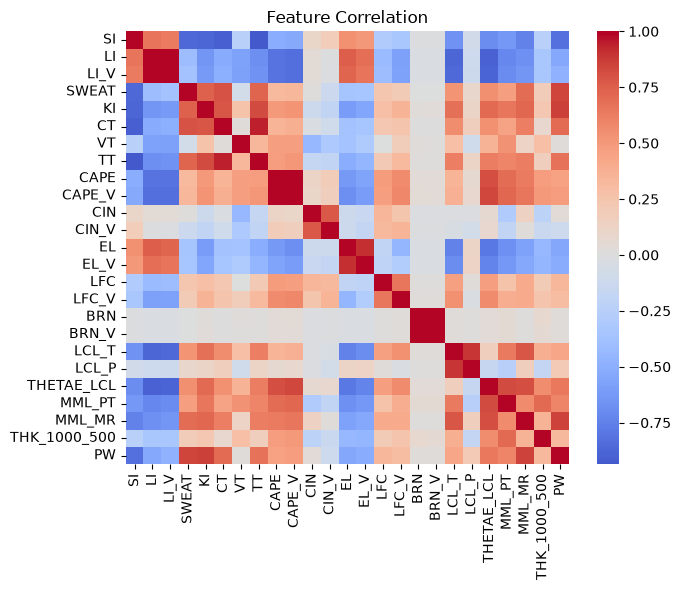

In [27]:
plt.figure(figsize=(7,6))

sns.heatmap(

    X_test.corr(),

    cmap="coolwarm",

    center=0

)

plt.title("Feature Correlation")

plt.tight_layout()

plt.savefig("Correlation_Heatmap.png",dpi=300)

plt.show()

In [28]:
print(df.shape)

print(df.info())

print(df.describe())

print(df.isnull().sum())

(1392, 26)
<class 'pandas.DataFrame'>
RangeIndex: 1392 entries, 0 to 1391
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   SI                1352 non-null   float64
 1   LI                1352 non-null   float64
 2   LI_V              1352 non-null   float64
 3   SWEAT             1352 non-null   float64
 4   KI                1352 non-null   float64
 5   CT                1352 non-null   float64
 6   VT                1352 non-null   float64
 7   TT                1352 non-null   float64
 8   CAPE              1392 non-null   float64
 9   CAPE_V            1392 non-null   float64
 10  CIN               1392 non-null   float64
 11  CIN_V             1392 non-null   float64
 12  EL                1138 non-null   float64
 13  EL_V              1128 non-null   float64
 14  LFC               1207 non-null   float64
 15  LFC_V             1213 non-null   float64
 16  BRN               1351 non-null   float64
